#### 13.7 Conditional Edges

In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from typing import Literal

In [2]:
class State(TypedDict):
    seed: int

graph_builder = StateGraph(State)

In [3]:
def node_one(state: State):    
    print("node_one:", state)
    return {}

def node_two(state: State):
    print("node_two:", state)
    return {}

def node_three(state: State):
    print("node_three:", state)
    return {}

def node_four(state: State):
    print("node_four:", state)
    return {}

In [4]:
graph_builder.add_node("node_one", node_one)
graph_builder.add_node("node_two", node_two)
graph_builder.add_node("node_three", node_three)
graph_builder.add_node("node_four", node_four)

# def decide_path(state: State) -> Literal["node_three", "node_four"]:
#     if state["seed"] % 2 == 0:
#         return "node_three"
#     else:
#         return "node_four"

def decide_path(state: State):
    return state["seed"] % 2 == 0

graph_builder.add_conditional_edges(
    START,     
    decide_path, 
    {
        True: "node_one",
        False: "node_two",
        "hello": END, # Maybe run
    },
)
graph_builder.add_edge("node_one", "node_two")
graph_builder.add_conditional_edges(
    "node_two", 
    decide_path, 
    {
        True: "node_three",
        False: "node_four",
        "hello": END, # Maybe run
    },
)
# node_three가 아무것도 반환하지 않기 때문에 END로 자동 귀결됨. (graph 참고)
graph_builder.add_edge("node_four", END)
graph_builder.add_edge("node_three", END)

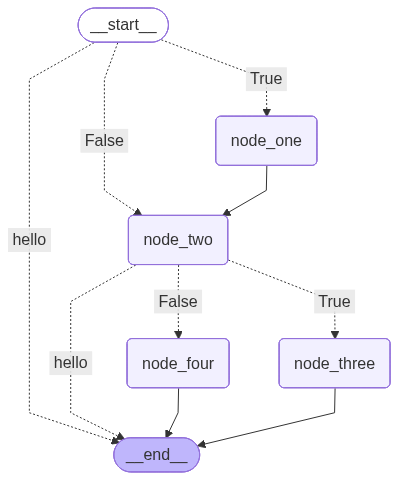

In [5]:
graph = graph_builder.compile()

graph

In [7]:
graph.invoke({
    "seed": 1
})

node_two: {'seed': 1}
node_four: {'seed': 1}


{'seed': 1}